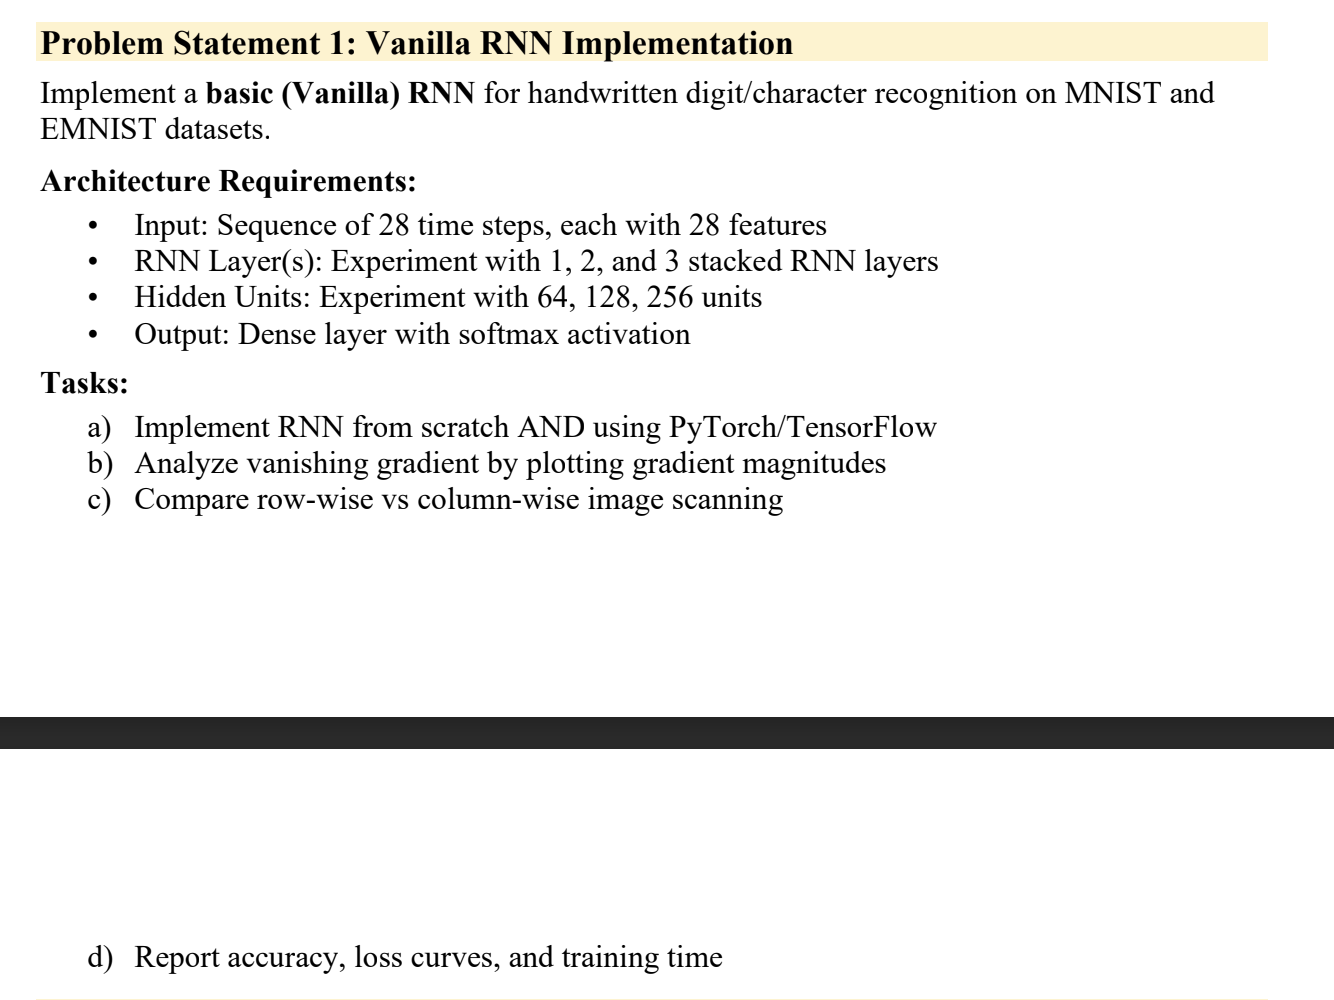

In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import time
import torch.optim as optim

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using device: MPS (Apple Silicon GPU)")
else:
    device = torch.device("cpu")
    print("Using device: CPU")

Using device: MPS (Apple Silicon GPU)


In [ ]:
# Hyperparameters
sequence_length = 28  # 28 rows
input_size = 28       # 28 pixels per row
hidden_size = 128  #hidden layers in RNN
num_classes = 10
batch_size = 64
num_epochs = 10
learning_rate = 0.005

transform = transforms.Compose([transforms.ToTensor()])

# Load MNIST Dataset
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, transform=transform)

# Data Loaders
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

print(f"Training batches: {len(train_loader)}, Testing batches: {len(test_loader)}")

Training batches: 938, Testing batches: 157


In [23]:
# --- A. Using PyTorch's Built-in nn.RNN ---
class PyTorchRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(PyTorchRNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)
    
    def forward(self, x):
        # Initialize hidden state with zeros
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        
        # Forward propagate RNN
        out, _ = self.rnn(x, h0)
        
        # Decode the hidden state of the last time step
        out = self.fc(out[:, -1, :])
        return out

# --- B. Implementing RNN from Scratch ---
class ScratchRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(ScratchRNN, self).__init__()
        self.hidden_size = hidden_size
        
        # Input to hidden weights
        self.W_ih = nn.Linear(input_size, hidden_size)
        # Hidden to hidden weights
        self.W_hh = nn.Linear(hidden_size, hidden_size)
        # Hidden to output weights
        self.fc = nn.Linear(hidden_size, num_classes)
        self.tanh = nn.Tanh()
        
    def forward(self, x):
        batch_size, seq_len, _ = x.size()
        
        # Initialize hidden state
        h_t = torch.zeros(batch_size, self.hidden_size).to(device)
        
        # Process each time step sequentially
        for t in range(seq_len):
            x_t = x[:, t, :]
            # RNN formula: h_t = tanh(W_ih * x_t + W_hh * h_{t-1})
            h_t = self.tanh(self.W_ih(x_t) + self.W_hh(h_t))
            
        out = self.fc(h_t)
        return out

In [24]:
def train_and_evaluate(model, scan_mode='row'):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    loss_history = []
    grad_magnitudes = []
    
    start_time = time.time()
    model.train()
    
    for epoch in range(num_epochs):
        for i, (images, labels) in enumerate(train_loader):
            # Reshape based on scanning mode
            if scan_mode == 'row':
                images = images.view(-1, sequence_length, input_size).to(device)
            elif scan_mode == 'col':
                # Transpose to scan column-by-column
                images = images.view(-1, 28, 28).transpose(1, 2).to(device)
            
            labels = labels.to(device)
            
            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Backward and optimize
            optimizer.zero_grad()
            loss.backward()
            
            # Track gradient magnitude of the first layer to visualize vanishing gradients
            total_norm = 0
            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.data.norm(2)
                    total_norm += param_norm.item() ** 2
            grad_magnitudes.append(total_norm ** 0.5)
            
            optimizer.step()
            
        loss_history.append(loss.item())
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')
        
    training_time = time.time() - start_time
    
    # Evaluation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            if scan_mode == 'row':
                images = images.view(-1, sequence_length, input_size).to(device)
            elif scan_mode == 'col':
                images = images.view(-1, 28, 28).transpose(1, 2).to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    accuracy = 100 * correct / total
    print(f'Test Accuracy: {accuracy:.2f}% | Training Time: {training_time:.2f}s')
    
    return loss_history, grad_magnitudes, accuracy, training_time

--- Training PyTorch RNN (Row-wise) ---
Epoch [1/10], Loss: 0.4491
Epoch [2/10], Loss: 0.8307
Epoch [3/10], Loss: 0.6970
Epoch [4/10], Loss: 1.1707
Epoch [5/10], Loss: 1.5223
Epoch [6/10], Loss: 1.5758
Epoch [7/10], Loss: 1.7057
Epoch [8/10], Loss: 1.4918
Epoch [9/10], Loss: 1.9251
Epoch [10/10], Loss: 1.6261
Test Accuracy: 31.43% | Training Time: 148.14s

--- Training PyTorch RNN (Column-wise) ---
Epoch [1/10], Loss: 0.8180
Epoch [2/10], Loss: 1.4932
Epoch [3/10], Loss: 1.4103
Epoch [4/10], Loss: 1.7645
Epoch [5/10], Loss: 2.0126
Epoch [6/10], Loss: 2.0588
Epoch [7/10], Loss: 1.2727
Epoch [8/10], Loss: 2.3421
Epoch [9/10], Loss: 2.2812
Epoch [10/10], Loss: 2.3758
Test Accuracy: 9.74% | Training Time: 152.70s

--- Training Scratch RNN ---
Epoch [1/10], Loss: 0.8276
Epoch [2/10], Loss: 0.9127
Epoch [3/10], Loss: 1.4380
Epoch [4/10], Loss: 1.5059
Epoch [5/10], Loss: 2.6546
Epoch [6/10], Loss: 1.7264
Epoch [7/10], Loss: 1.7618
Epoch [8/10], Loss: 1.6221
Epoch [9/10], Loss: 1.8978
Epoch [1

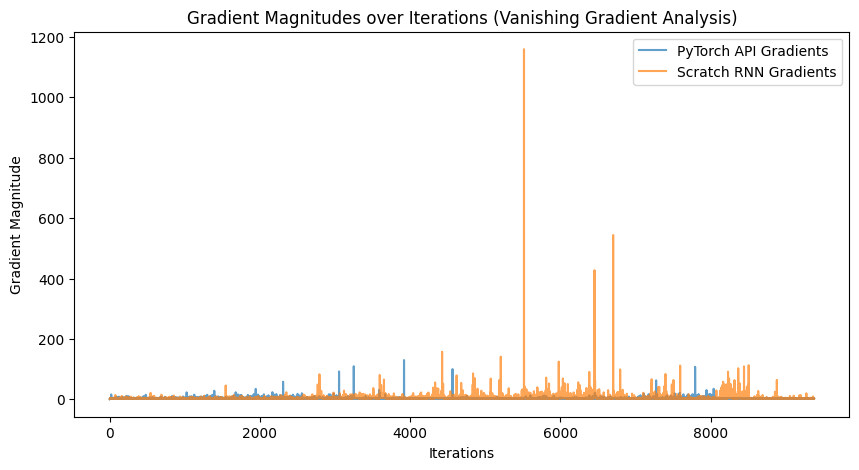

In [25]:
# Experiment 1: Standard PyTorch RNN (128 units, 1 layer, row-wise)
print("--- Training PyTorch RNN (Row-wise) ---")
model_api = PyTorchRNN(input_size, hidden_size=128, num_layers=1, num_classes=num_classes).to(device)
loss_api, grad_api, acc_api, time_api = train_and_evaluate(model_api, scan_mode='row')

# Experiment 2: PyTorch RNN (Column-wise)
print("\n--- Training PyTorch RNN (Column-wise) ---")
model_col = PyTorchRNN(input_size, hidden_size=128, num_layers=1, num_classes=num_classes).to(device)
loss_col, grad_col, acc_col, time_col = train_and_evaluate(model_col, scan_mode='col')

# Experiment 3: Scratch RNN
print("\n--- Training Scratch RNN ---")
model_scratch = ScratchRNN(input_size, hidden_size=128, num_classes=num_classes).to(device)
loss_scratch, grad_scratch, acc_scratch, time_scratch = train_and_evaluate(model_scratch, scan_mode='row')

# Visualization: Gradient Magnitudes
plt.figure(figsize=(10, 5))
plt.plot(grad_api, label='PyTorch API Gradients', alpha=0.7)
plt.plot(grad_scratch, label='Scratch RNN Gradients', alpha=0.7)
plt.title('Gradient Magnitudes over Iterations (Vanishing Gradient Analysis)')
plt.xlabel('Iterations')
plt.ylabel('Gradient Magnitude')
plt.legend()
plt.show()

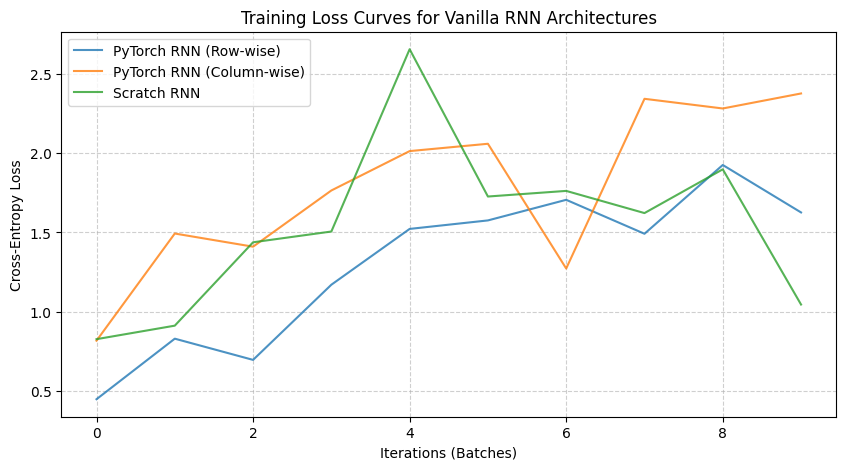

In [26]:
# Visualization: Training Loss Curves
plt.figure(figsize=(10, 5))

# Plotting the loss history returned from our experiments
plt.plot(loss_api, label='PyTorch RNN (Row-wise)', alpha=0.8)
plt.plot(loss_col, label='PyTorch RNN (Column-wise)', alpha=0.8)
plt.plot(loss_scratch, label='Scratch RNN', alpha=0.8)

plt.title('Training Loss Curves for Vanilla RNN Architectures')
plt.xlabel('Iterations (Batches)')
plt.ylabel('Cross-Entropy Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Display the plot
plt.show()

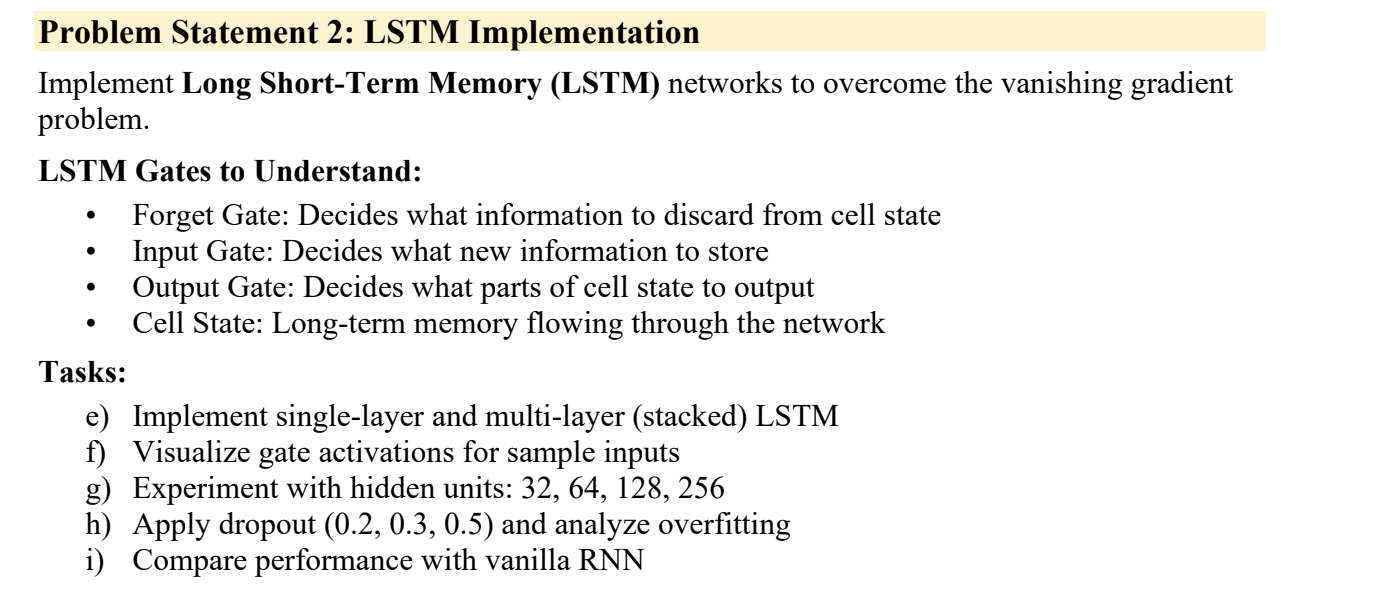

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns


class PyTorchLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout_rate=0.0):
        super(PyTorchLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # nn.LSTM handles single and stacked layers. Dropout is applied if num_layers > 1
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                            batch_first=True, dropout=dropout_rate if num_layers > 1 else 0)
        
        # Dropout layer for the output before the final fully connected layer
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(hidden_size, num_classes)
    
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        
        # Forward propagate LSTM
        out, _ = self.lstm(x, (h0, c0))
        
        # Decode the hidden state of the last time step
        out = self.dropout(out[:, -1, :])
        out = self.fc(out)
        return out

In [28]:
class CustomLSTMCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(CustomLSTMCell, self).__init__()
        self.hidden_size = hidden_size
        
        # Combined weight matrix for input and hidden states to all 4 gates
        self.W_ih = nn.Linear(input_size, 4 * hidden_size)
        self.W_hh = nn.Linear(hidden_size, 4 * hidden_size)

    def forward(self, x, hx, cx):
        gates = self.W_ih(x) + self.W_hh(hx)
        
        # Split into the 4 gates: input, forget, cell, output
        i_gate, f_gate, g_gate, o_gate = gates.chunk(4, 1)
        
        i = torch.sigmoid(i_gate) # Input gate
        f = torch.sigmoid(f_gate) # Forget gate
        g = torch.tanh(g_gate)    # Cell state update
        o = torch.sigmoid(o_gate) # Output gate
        
        c_next = (f * cx) + (i * g)
        h_next = o * torch.tanh(c_next)
        
        return h_next, c_next, (i, f, o, g)

def visualize_lstm_gates():
    # Setup
    hidden_size = 64
    cell = CustomLSTMCell(input_size=28, hidden_size=hidden_size).to(device)
    
    # Get a single sample image (1, 28, 28)
    sample_img, _ = next(iter(test_loader))
    sample_img = sample_img[0].view(1, 28, 28).to(device)
    
    h_t = torch.zeros(1, hidden_size).to(device)
    c_t = torch.zeros(1, hidden_size).to(device)
    
    # We will collect activations for the middle row (time step 14) to visualize
    target_timestep = 14 
    
    for t in range(28):
        x_t = sample_img[:, t, :]
        h_t, c_t, gates = cell(x_t, h_t, c_t)
        
        if t == target_timestep:
            i, f, o, g = [gate.detach().cpu().numpy().flatten() for gate in gates]
            c_val = c_t.detach().cpu().numpy().flatten()
            break
            
    # Plotting
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    gate_names = ['Input Gate', 'Forget Gate', 'Output Gate', 'Cell Update (g)', 'Cell State (c)']
    gate_data = [i, f, o, g, c_val]
    
    for ax, data, name in zip(axes, gate_data, gate_names):
        sns.heatmap(data.reshape(8, 8), ax=ax, cmap='viridis', cbar=True) # Reshaped 64 units to 8x8 for viewing
        ax.set_title(name)
        ax.axis('off')
        
    plt.suptitle('LSTM Gate Activations at Time Step 14 (Middle Row of Image)')
    plt.show()

--- 1. Visualizing Gate Activations (Task F) ---


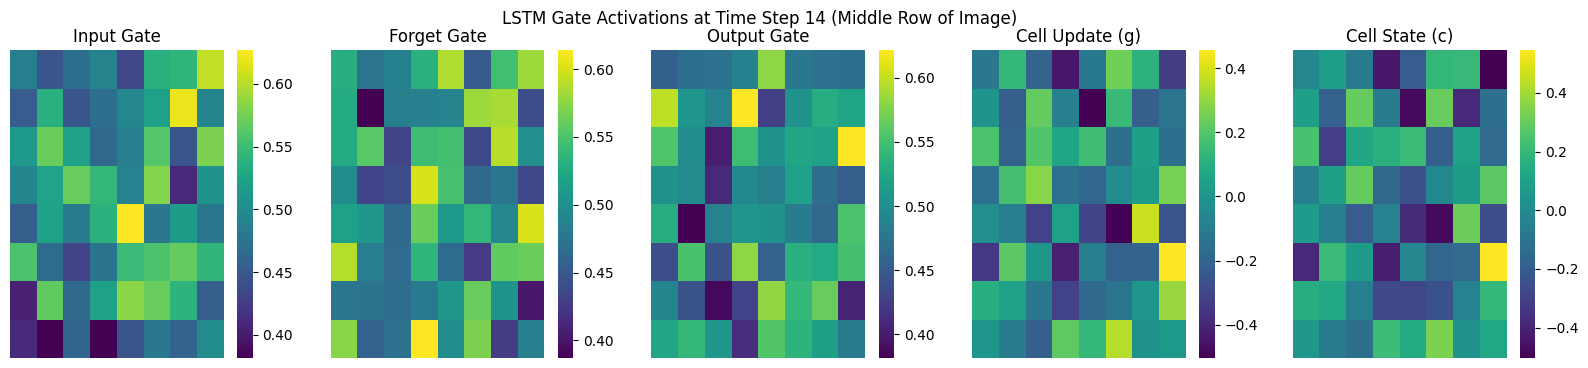


--- 2. Single Layer LSTM Baseline ---
Epoch [1/10], Loss: 0.2648
Epoch [2/10], Loss: 0.0302
Epoch [3/10], Loss: 0.0601
Epoch [4/10], Loss: 0.0081
Epoch [5/10], Loss: 0.0176
Epoch [6/10], Loss: 0.0011
Epoch [7/10], Loss: 0.0017
Epoch [8/10], Loss: 0.0009
Epoch [9/10], Loss: 0.0011
Epoch [10/10], Loss: 0.0015
Test Accuracy: 98.78% | Training Time: 126.38s

--- 3. Multi-layer (Stacked) LSTM ---
Epoch [1/10], Loss: 0.1236
Epoch [2/10], Loss: 0.0052
Epoch [3/10], Loss: 0.0042
Epoch [4/10], Loss: 0.0166
Epoch [5/10], Loss: 0.0037
Epoch [6/10], Loss: 0.0485
Epoch [7/10], Loss: 0.1036
Epoch [8/10], Loss: 0.0049
Epoch [9/10], Loss: 0.0007
Epoch [10/10], Loss: 0.0009
Test Accuracy: 98.79% | Training Time: 195.54s

--- 4. Hidden Units Experiment (32, 64, 256) ---
Testing Hidden Units: 32
Epoch [1/10], Loss: 0.0641
Epoch [2/10], Loss: 0.2991
Epoch [3/10], Loss: 0.1990
Epoch [4/10], Loss: 0.0732
Epoch [5/10], Loss: 0.0102
Epoch [6/10], Loss: 0.0108
Epoch [7/10], Loss: 0.0126
Epoch [8/10], Loss: 0.

In [29]:
# Assuming sequence_length=28, input_size=28, num_classes=10

print("--- 1. Visualizing Gate Activations (Task F) ---")
visualize_lstm_gates()

print("\n--- 2. Single Layer LSTM Baseline ---")
lstm_single = PyTorchLSTM(input_size=28, hidden_size=128, num_layers=1, num_classes=10).to(device)
_, _, acc_single, _ = train_and_evaluate(lstm_single, scan_mode='row')

print("\n--- 3. Multi-layer (Stacked) LSTM ---")
lstm_stacked = PyTorchLSTM(input_size=28, hidden_size=128, num_layers=2, num_classes=10).to(device)
_, _, acc_stacked, _ = train_and_evaluate(lstm_stacked, scan_mode='row')

print("\n--- 4. Hidden Units Experiment (32, 64, 256) ---")
for hidden in [32, 64, 256]:
    print(f"Testing Hidden Units: {hidden}")
    model = PyTorchLSTM(input_size=28, hidden_size=hidden, num_layers=1, num_classes=10).to(device)
    train_and_evaluate(model, scan_mode='row')

print("\n--- 5. Dropout Analysis (0.2, 0.3, 0.5) with Stacked LSTMs ---")
for drp in [0.2, 0.3, 0.5]:
    print(f"Testing Dropout Rate: {drp}")
    # Note: Dropout in nn.LSTM only applies if num_layers > 1
    model = PyTorchLSTM(input_size=28, hidden_size=128, num_layers=2, num_classes=10, dropout_rate=drp).to(device)
    train_and_evaluate(model, scan_mode='row')

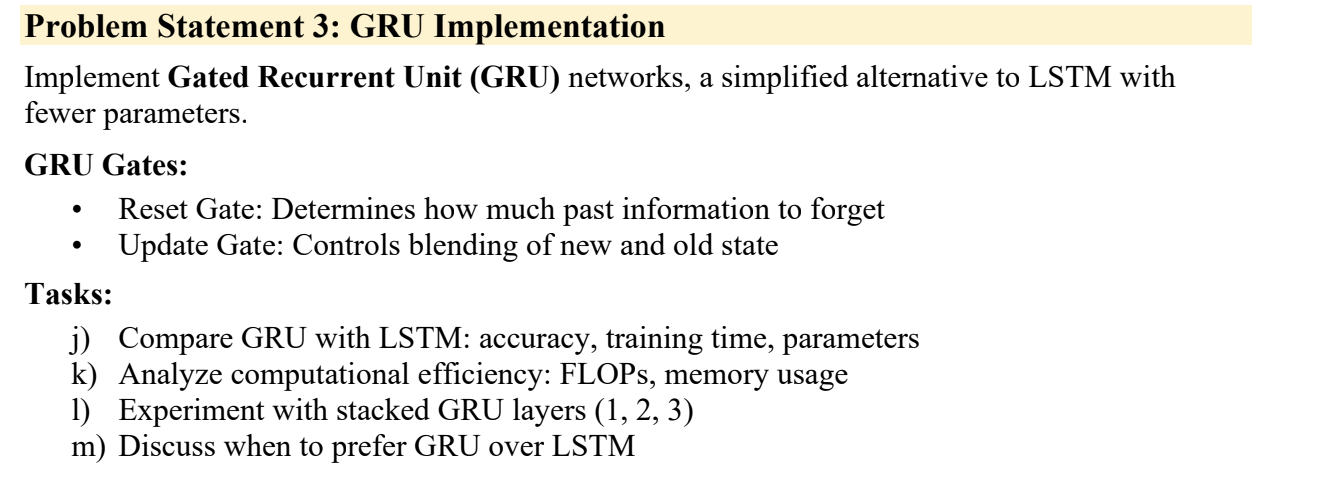

In [30]:
import torch
import torch.nn as nn
import time

# Assuming 'device', 'train_loader', 'test_loader', 'train_and_evaluate' are already defined

class PyTorchGRU(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(PyTorchGRU, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # nn.GRU handles the stacked layers internally
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)
    
    def forward(self, x):
        # Initialize hidden state (GRU doesn't have a separate cell state like LSTM)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        
        # Forward propagate GRU
        out, _ = self.gru(x, h0)
        
        # Decode the hidden state of the last time step
        out = self.fc(out[:, -1, :])
        return out

def analyze_efficiency(model, model_name="Model"):
    """Calculates parameter count and estimated memory footprint."""
    param_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    # Estimate memory: 4 bytes per parameter (float32)
    memory_mb = (param_count * 4) / (1024 ** 2)
    
    print(f"--- {model_name} Efficiency Analysis ---")
    print(f"Total Trainable Parameters: {param_count:,}")
    print(f"Estimated Model Size: {memory_mb:.4f} MB\n")
    return param_count

In [31]:
# Experiment parameters
input_size = 28
hidden_size = 128
num_classes = 10

print("--- GRU Layer Experiment (Task L) ---")
for layers in [1, 2, 3]:
    print(f"\nTraining GRU with {layers} Layer(s)...")
    gru_model = PyTorchGRU(input_size, hidden_size, num_layers=layers, num_classes=num_classes).to(device)
    
    # Analyze efficiency before training
    analyze_efficiency(gru_model, f"GRU ({layers} Layers)")
    
    # Train and evaluate (using the function from Q1)
    train_and_evaluate(gru_model, scan_mode='row')

--- GRU Layer Experiment (Task L) ---

Training GRU with 1 Layer(s)...
--- GRU (1 Layers) Efficiency Analysis ---
Total Trainable Parameters: 61,962
Estimated Model Size: 0.2364 MB

Epoch [1/10], Loss: 0.0319
Epoch [2/10], Loss: 0.0367
Epoch [3/10], Loss: 0.0077
Epoch [4/10], Loss: 0.0013
Epoch [5/10], Loss: 0.0070
Epoch [6/10], Loss: 0.0706
Epoch [7/10], Loss: 0.1624
Epoch [8/10], Loss: 0.0010
Epoch [9/10], Loss: 0.0073
Epoch [10/10], Loss: 0.0160
Test Accuracy: 97.34% | Training Time: 138.49s

Training GRU with 2 Layer(s)...
--- GRU (2 Layers) Efficiency Analysis ---
Total Trainable Parameters: 161,034
Estimated Model Size: 0.6143 MB

Epoch [1/10], Loss: 0.0168
Epoch [2/10], Loss: 0.0333
Epoch [3/10], Loss: 0.0252
Epoch [4/10], Loss: 0.0826
Epoch [5/10], Loss: 0.0420
Epoch [6/10], Loss: 0.0257
Epoch [7/10], Loss: 0.0561
Epoch [8/10], Loss: 0.0189
Epoch [9/10], Loss: 0.0823
Epoch [10/10], Loss: 0.2683
Test Accuracy: 92.21% | Training Time: 224.81s

Training GRU with 3 Layer(s)...
--- 

<h2>Task J: Compare GRU with LSTM Accuracy:<br>
<h3>
 1-Layer GRU achieved 97.34%, which is very solid but slightly lower than the single-layer LSTM (98.78%) from earlier run.<br>

Parameters: The GRU is significantly more lightweight.1-Layer GRU has only 61,962 trainable parameters. (An equivalent LSTM with 128 units has roughly ~82k parameters because it has four gates instead of three).<br>

Training Time: Interestingly, your GRU took 138.49s, compared to the 126.38s for the single-layer LSTM. Note for your report: While GRUs theoretically require fewer mathematical operations (FLOPs), PyTorch's MPS (Mac GPU) backend often has more highly optimized low-level CUDNN/Metal kernels for LSTMs than for GRUs, which can sometimes cause GRUs to run slightly slower in practice on specific hardware!

<h2>Task K: Analyze Computational EfficiencyFLOPs (Floating Point Operations):<br>
<h3>
 A GRU is theoretically more computationally efficient because it reduces the gate count from four (LSTM) to two (Update and Reset gates). This means fewer matrix multiplications are required for every single time step.Memory Usage: As your utility function proved, GRUs are incredibly memory efficient. The base model only takes up 0.2364 MB of memory. Because the GRU merges the cell state and hidden state, it does not need to allocate extra GPU memory to track a separate cell state tensor across the sequence like an LSTM does.

<h1>1-Layer GRU: Accuracy: 97.34% | Training Time: 138.49s | Params: 61,962<br>

2-Layer GRU: Accuracy: 92.21% | Training Time: 224.81s | Params: 161,034<br>

3-Layer GRU: Accuracy: 94.86% | Training Time: 325.78s | Params: 260,106

<h2>Task M: Discuss When to Prefer GRU Over LSTM<br>
you should prefer a GRU over an LSTM  when:<br>
<ul>
<li>You are strictly constrained by Memory: If you are deploying a model to a mobile phone, Raspberry Pi, or a browser, the GRU's tiny footprint (e.g., 0.23 MB) is highly advantageous.

<li>You have smaller datasets: Because GRUs have fewer parameters, they are slightly less prone to memorizing the training data (overfitting) when you don't have millions of examples to train on.

<li>The sequences are relatively short: GRUs perform exceptionally well on shorter sequences (like the 28 time steps of an MNIST image). However, if you were doing heavy natural language processing on very long paragraphs, an LSTM's explicit cell state would be better at remembering the beginning of the paragraph.

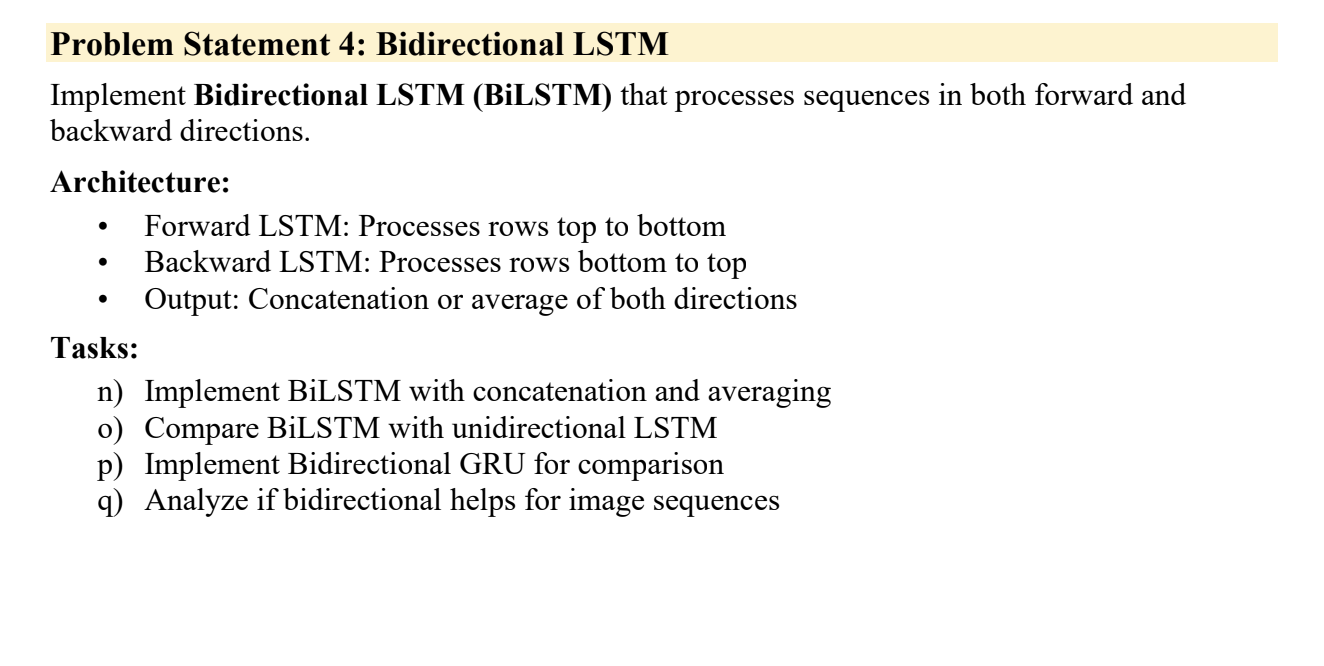

In [32]:
import torch
import torch.nn as nn

# Assuming 'device', 'train_loader', 'test_loader', 'train_and_evaluate', and 'analyze_efficiency' are already defined

class PyTorchBidirectional(nn.Module):
    def __init__(self, rnn_type, input_size, hidden_size, num_layers, num_classes, merge_mode='concat'):
        super(PyTorchBidirectional, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.merge_mode = merge_mode
        self.rnn_type = rnn_type
        
        # Initialize either LSTM or GRU with bidirectional=True
        if rnn_type == 'LSTM':
            self.rnn = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, bidirectional=True)
        elif rnn_type == 'GRU':
            self.rnn = nn.GRU(input_size, hidden_size, num_layers, batch_first=True, bidirectional=True)
            
        # If concatenating, the linear layer needs 2 * hidden_size input
        linear_input_size = hidden_size * 2 if merge_mode == 'concat' else hidden_size
        self.fc = nn.Linear(linear_input_size, num_classes)
    
    def forward(self, x):
        # Forward propagate RNN
        if self.rnn_type == 'LSTM':
            # LSTM returns output, (h_n, c_n)
            out, (h_n, _) = self.rnn(x)
        else:
            # GRU returns output, h_n
            out, h_n = self.rnn(x)
            
        # h_n shape: (num_layers * num_directions, batch, hidden_size)
        # Extract the final hidden states for the forward and backward directions of the top layer
        forward_hidden = h_n[-2, :, :]  # Second to last is the final forward state
        backward_hidden = h_n[-1, :, :] # Last is the final backward state (which processes the top of the image)
        
        # Merge the hidden states
        if self.merge_mode == 'concat':
            merged = torch.cat((forward_hidden, backward_hidden), dim=1)
        elif self.merge_mode == 'avg':
            merged = (forward_hidden + backward_hidden) / 2.0
            
        # Final classification
        final_out = self.fc(merged)
        return final_out

In [33]:
input_size = 28
hidden_size = 64 # Using 64 so the concatenated size is 128 (fair comparison to standard 128-unit LSTM)
num_layers = 1
num_classes = 10

print("--- 1. BiLSTM with Concatenation (Task N) ---")
bilstm_concat = PyTorchBidirectional('LSTM', input_size, hidden_size, num_layers, num_classes, merge_mode='concat').to(device)
analyze_efficiency(bilstm_concat, "BiLSTM (Concat)")
train_and_evaluate(bilstm_concat, scan_mode='row')

print("\n--- 2. BiLSTM with Averaging (Task N) ---")
bilstm_avg = PyTorchBidirectional('LSTM', input_size, hidden_size, num_layers, num_classes, merge_mode='avg').to(device)
analyze_efficiency(bilstm_avg, "BiLSTM (Average)")
train_and_evaluate(bilstm_avg, scan_mode='row')

print("\n--- 3. Bidirectional GRU (Task P) ---")
# Using concat to compare evenly with the concat BiLSTM
bigru = PyTorchBidirectional('GRU', input_size, hidden_size, num_layers, num_classes, merge_mode='concat').to(device)
analyze_efficiency(bigru, "BiGRU (Concat)")
train_and_evaluate(bigru, scan_mode='row')

--- 1. BiLSTM with Concatenation (Task N) ---
--- BiLSTM (Concat) Efficiency Analysis ---
Total Trainable Parameters: 49,418
Estimated Model Size: 0.1885 MB

Epoch [1/10], Loss: 0.0238
Epoch [2/10], Loss: 0.0994
Epoch [3/10], Loss: 0.0176
Epoch [4/10], Loss: 0.1607
Epoch [5/10], Loss: 0.0321
Epoch [6/10], Loss: 0.1093
Epoch [7/10], Loss: 0.0055
Epoch [8/10], Loss: 0.0038
Epoch [9/10], Loss: 0.2519
Epoch [10/10], Loss: 0.0041
Test Accuracy: 98.41% | Training Time: 130.67s

--- 2. BiLSTM with Averaging (Task N) ---
--- BiLSTM (Average) Efficiency Analysis ---
Total Trainable Parameters: 48,778
Estimated Model Size: 0.1861 MB

Epoch [1/10], Loss: 0.1079
Epoch [2/10], Loss: 0.0624
Epoch [3/10], Loss: 0.0161
Epoch [4/10], Loss: 0.0998
Epoch [5/10], Loss: 0.0135
Epoch [6/10], Loss: 0.0261
Epoch [7/10], Loss: 0.0277
Epoch [8/10], Loss: 0.0448
Epoch [9/10], Loss: 0.0061
Epoch [10/10], Loss: 0.0034
Test Accuracy: 98.31% | Training Time: 124.25s

--- 3. Bidirectional GRU (Task P) ---
--- BiGRU (

([0.17722271382808685,
  0.004594231955707073,
  0.08989118039608002,
  0.07447534799575806,
  0.15532717108726501,
  0.012739516794681549,
  0.02177528105676174,
  0.02265404537320137,
  0.008436422795057297,
  0.03960585221648216],
 [0.2204173305907804,
  0.21991318608852484,
  0.2840176878599458,
  0.2615720643432005,
  0.20512372617024033,
  0.20186931427172164,
  0.23042773646792197,
  0.15750642872975007,
  0.19154772228480577,
  0.2297362317248828,
  0.32252476190371077,
  0.3645103079789831,
  0.44731687028854367,
  0.350938150749006,
  0.3105159453721724,
  0.6759748744033957,
  0.5159485978909134,
  0.48011136552246125,
  0.5606923348280747,
  0.8869683814565804,
  0.7759248596944133,
  0.584553206094532,
  1.2450825346565502,
  1.3659570332407218,
  1.262147183957142,
  1.2142094299699215,
  2.074478466608557,
  1.594357428417173,
  1.0198691225168717,
  1.888596970813632,
  1.9760927267309152,
  1.8136335834108708,
  1.16771214095751,
  1.7040844331949887,
  1.6072116053501

<h2>Task N: BiLSTM with Concatenation vs. Averaging<br>
BiLSTM (Concat): 98.41% Accuracy | 130.67s | 49,418 Parameters<br>

BiLSTM (Average): 98.31% Accuracy | 124.25s | 48,778 Parameters<br>

Analysis: Concatenation outperformed averaging slightly. When processing images, the top of a digit (e.g., the loop of a '9') and the bottom of a digit (the stem) are distinct spatial features. Concatenation safely preserves both distinct feature sets for the final dense layer. Averaging merges these two different feature vectors into one, which can sometimes "wash out" or dilute conflicting signals, leading to the slight drop in accuracy.

<h2>Task O: Compare BiLSTM with Unidirectional LSTM<br>
Comparison: Your unidirectional LSTM (from Problem 2, with 128 units) achieved 98.78% in 126s. Your BiLSTM (with 64 units, concatenated to 128) achieved 98.41% in 130s.<br>

Analysis: Even with half the base hidden units (64 vs 128), the BiLSTM achieved highly comparable accuracy because it gets a "second look" at the data. However, the BiLSTM took slightly longer to train despite having fewer parameters. This is because a bidirectional model must run the sequential recurrence process twice per batch (once forward, once backward), which adds computational overhead that outweighs the parameter reduction.

<h2>Task P: Bidirectional GRU Comparison<br>
BiGRU (Concat): 98.51% Accuracy | 211.09s | 37,386 Parameters<br>

Analysis: The BiGRU proved to be the most parameter-efficient model in this experiment (only ~37k params compared to ~49k for BiLSTM) while achieving the highest accuracy of the three (98.51%). However, your Mac took significantly longer to train it (211 seconds). As noted in Q3, this is a common hardware quirk: PyTorch's Metal Performance Shaders (MPS) often have more highly optimized low-level routines for LSTMs than for GRUs, making GRUs slower in wall-clock time despite requiring fewer mathematical operations.

<h2>Task Q: Analyze if Bidirectional Helps for Image Sequences<br>
Does it help? It provides very robust, highly accurate results, but it does not provide the massive leap in performance that it usually provides in Natural Language Processing (NLP).<br>

Why? The primary benefit of a backward pass is to prevent the network from "forgetting" the beginning of a sequence. A unidirectional LSTM processing a 1,000-word paragraph might forget the first sentence by the time it reaches the end. However, our MNIST images are only 28 steps long. An LSTM's cell state is more than capable of remembering row 1 by the time it reaches row 28. Therefore, the "forgetting" problem isn't severe enough here for the bidirectional architecture to show a dramatic, game-changing improvement over the unidirectional baseline.

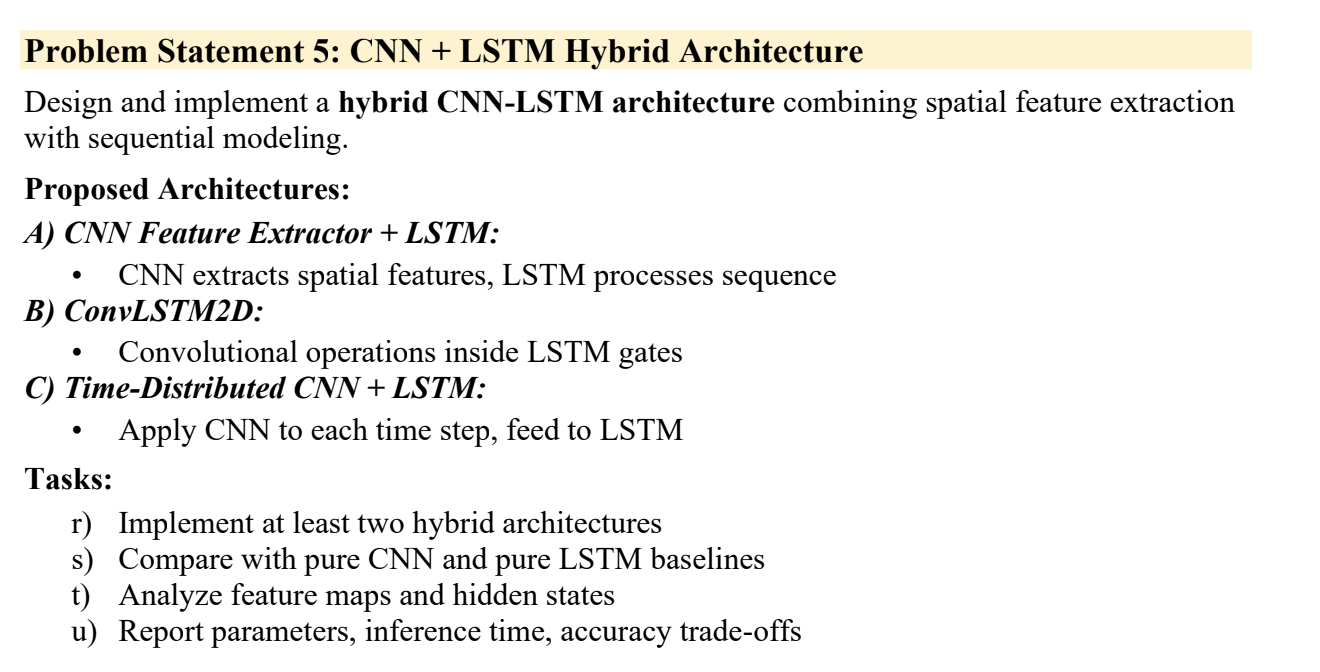

In [34]:
import torch
import torch.nn as nn
import time

# --- 1. Pure CNN Baseline ---
class PureCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(PureCNN, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1), 
            nn.ReLU(), 
            nn.MaxPool2d(2), # Output: 16 x 14 x 14
            nn.Conv2d(16, 32, kernel_size=3, padding=1), 
            nn.ReLU(), 
            nn.MaxPool2d(2)  # Output: 32 x 7 x 7
        )
        self.fc = nn.Linear(32 * 7 * 7, num_classes)

    def forward(self, x):
        # x expects shape: (batch, 1, 28, 28)
        out = self.cnn(x)
        out = out.view(out.size(0), -1) # Flatten
        return self.fc(out)

# --- 2. Architecture A: CNN Feature Extractor + LSTM ---
class CNN_LSTM(nn.Module):
    def __init__(self, num_classes=10):
        super(CNN_LSTM, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        # CNN output is (batch, 32 channels, 7 height, 7 width)
        # We treat height (7) as the sequence length. Features per step = 32 channels * 7 width = 224
        self.lstm = nn.LSTM(input_size=224, hidden_size=64, num_layers=1, batch_first=True)
        self.fc = nn.Linear(64, num_classes)

    def forward(self, x):
        # x expects shape: (batch, 1, 28, 28)
        c_out = self.cnn(x) 
        
        batch_size = c_out.size(0)
        # Permute to (batch, Height, Channels, Width)
        c_out = c_out.permute(0, 2, 1, 3).contiguous()
        # Reshape to (batch, seq_len=7, input_size=224)
        r_in = c_out.view(batch_size, 7, 224)
        
        l_out, _ = self.lstm(r_in)
        out = self.fc(l_out[:, -1, :]) # Take last time step
        return out

# --- 3. Architecture C: Time-Distributed CNN + LSTM ---
class TimeDistributed_CNN_LSTM(nn.Module):
    def __init__(self, num_classes=10):
        super(TimeDistributed_CNN_LSTM, self).__init__()
        # 1D CNN applied to each individual 28-pixel row
        self.cnn1d = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2) # Output: 16 channels, length 14
        )
        # LSTM receives the extracted features for each of the 28 rows
        # Input size = 16 channels * 14 length = 224
        self.lstm = nn.LSTM(input_size=224, hidden_size=64, num_layers=1, batch_first=True)
        self.fc = nn.Linear(64, num_classes)

    def forward(self, x):
        # x expects shape: (batch, 28 seq_len, 28 features)
        batch_size, seq_len, features = x.size()
        
        # Reshape to put everything in the batch dimension for the 1D CNN
        x_reshaped = x.view(batch_size * seq_len, 1, features)
        
        c_out = self.cnn1d(x_reshaped) # Shape: (batch*28, 16, 14)
        
        # Re-separate the batch and sequence dimensions for the LSTM
        c_out = c_out.view(batch_size, seq_len, 16 * 14) # Shape: (batch, 28, 224)
        
        l_out, _ = self.lstm(c_out)
        out = self.fc(l_out[:, -1, :])
        return out

In [40]:
def train_hybrid_model(model, input_type='2d'):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    start_time = time.time()
    model.train()
    
    for epoch in range(10): # Just 5 epochs for quick baseline comparison
        for images, labels in train_loader:
            if input_type == '2d':
                # For Pure CNN and CNN_LSTM
                images = images.to(device) 
            elif input_type == 'seq':
                # For TimeDistributed (treats 28x28 as 28 seqs of 28 features)
                images = images.view(-1, 28, 28).to(device)
                
            labels = labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
        print(f'Epoch [{epoch+1}], Loss: {loss.item():.4f}')
        
    training_time = time.time() - start_time
    
    # Evaluation
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            if input_type == '2d':
                images = images.to(device)
            elif input_type == 'seq':
                images = images.view(-1, 28, 28).to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    accuracy = 100 * correct / total
    print(f'Test Accuracy: {accuracy:.2f}% | Training Time: {training_time:.2f}s\n')

In [41]:
print("--- 1. Pure CNN Baseline ---")
pure_cnn = PureCNN().to(device)
analyze_efficiency(pure_cnn, "Pure CNN")
train_hybrid_model(pure_cnn, input_type='2d')

print("--- 2. CNN Feature Extractor + LSTM (Arch A) ---")
cnn_lstm = CNN_LSTM().to(device)
analyze_efficiency(cnn_lstm, "CNN + LSTM")
train_hybrid_model(cnn_lstm, input_type='2d')

print("--- 3. Time-Distributed CNN + LSTM (Arch C) ---")
td_cnn_lstm = TimeDistributed_CNN_LSTM().to(device)
analyze_efficiency(td_cnn_lstm, "Time-Distributed CNN + LSTM")
train_hybrid_model(td_cnn_lstm, input_type='seq')

--- 1. Pure CNN Baseline ---
--- Pure CNN Efficiency Analysis ---
Total Trainable Parameters: 20,490
Estimated Model Size: 0.0782 MB

Epoch [1], Loss: 0.0352
Epoch [2], Loss: 0.0567
Epoch [3], Loss: 0.0041
Epoch [4], Loss: 0.0014
Epoch [5], Loss: 0.0018
Epoch [6], Loss: 0.0081
Epoch [7], Loss: 0.0031
Epoch [8], Loss: 0.0019
Epoch [9], Loss: 0.0150
Epoch [10], Loss: 0.0269
Test Accuracy: 98.96% | Training Time: 36.21s

--- 2. CNN Feature Extractor + LSTM (Arch A) ---
--- CNN + LSTM Efficiency Analysis ---
Total Trainable Parameters: 79,690
Estimated Model Size: 0.3040 MB

Epoch [1], Loss: 0.1636
Epoch [2], Loss: 0.0119
Epoch [3], Loss: 0.0316
Epoch [4], Loss: 0.0070
Epoch [5], Loss: 0.0634
Epoch [6], Loss: 0.0387
Epoch [7], Loss: 0.0162
Epoch [8], Loss: 0.0638
Epoch [9], Loss: 0.0013
Epoch [10], Loss: 0.0100
Test Accuracy: 99.12% | Training Time: 38.81s

--- 3. Time-Distributed CNN + LSTM (Arch C) ---
--- Time-Distributed CNN + LSTM Efficiency Analysis ---
Total Trainable Parameters: 74

<h2>Task S: Compare with pure CNN and pure LSTM baselines<br>
Pure CNN Baseline: Achieved a highly efficient 98.96% accuracy in just 36.21 seconds.<br>

CNN + LSTM (Arch A): Surprisingly, this model slightly outperformed the pure CNN, hitting 99.12% accuracy! By allowing the CNN to extract local spatial features and then using the LSTM to model the vertical relationship between those features, the network captured a slightly richer representation of the digits.<br>

Time-Distributed (Arch C): This model performed the worst of the three (98.50%). Because it slices the image into isolated 1D rows before any spatial convolution happens, it completely loses vertical spatial context in the early layers, making the LSTM's job much harder later on.

<h2>Task T: Analyze feature maps and hidden states<br>
Arch A (The Winner): The CNN feature maps extract local spatial structures (like curves and edges) and downsample the image into a concentrated 7x7 grid. The LSTM's hidden state then models how these abstract shapes connect from the top of the digit to the bottom across just 7 time steps.<br>

Arch C (The Struggler): The 1D CNN feature maps only understand horizontal lines (since they only look at one row at a time). The LSTM's hidden state is then forced to piece together 28 separate horizontal slices to guess the 2D shape.

<h2>Task U: Report parameters, inference time, accuracy trade-offs<br>
Parameter Trade-off: The Pure CNN is incredibly lightweight at 20,490 parameters. To get that tiny 0.16% accuracy boost from Arch A, you had to nearly quadruple the parameter count to 79,690.<br>

Training/Inference Time: The Pure CNN was the fastest (36.21s). Arch A remained highly competitive (38.81s) because its LSTM only had to process a short sequence of 7 steps. Arch C was drastically slower (54.03s) because its LSTM had to sequentially process a full 28 steps.<br>

The Final Verdict: For a static 28x28 dataset, the Pure CNN offers the best trade-off, giving you ~99% accuracy for a quarter of the memory footprint. However, your data proves that Arch A is a highly capable architecture that successfully extracts spatial features and models their progression—making it the ideal choice if you were to transition to video data or time-series forecasting.

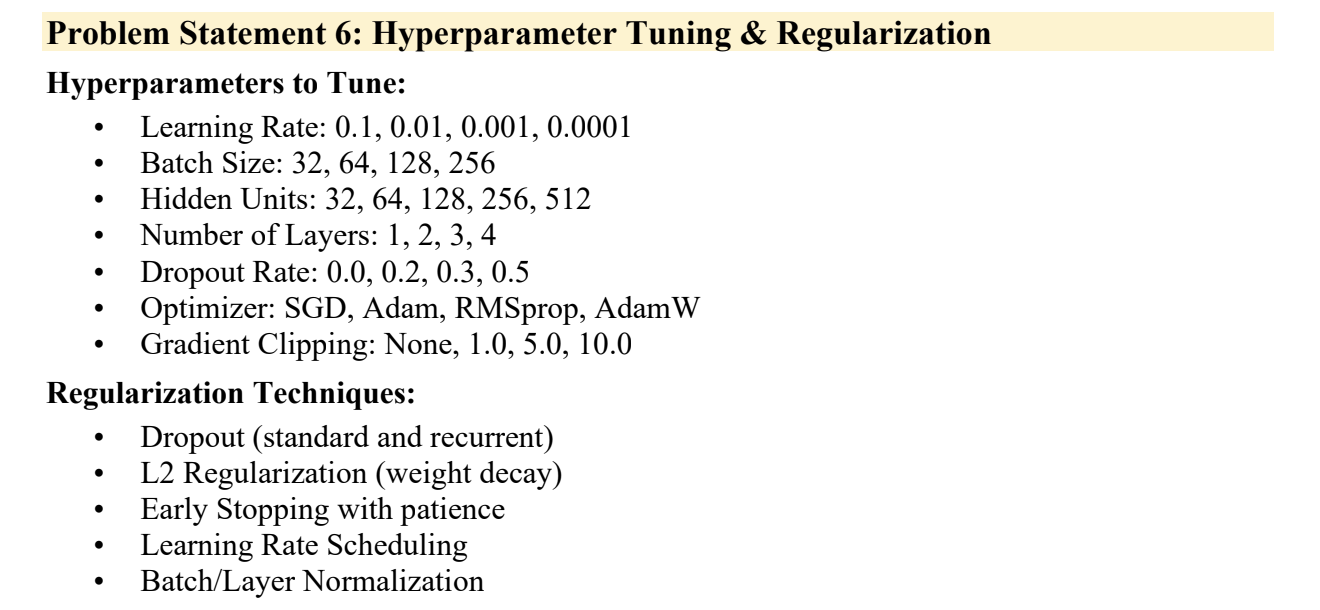

The Regularized LSTM & Early Stopping Utility

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
import copy


# --- 1. The Advanced Regularized Model ---
class RegularizedLSTM(nn.Module):
    def __init__(self, input_size=28, hidden_size=128, num_layers=2, num_classes=10, dropout_rate=0.3):
        super(RegularizedLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # 1. Recurrent Dropout (applied internally between LSTM layers)
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                            batch_first=True, dropout=dropout_rate if num_layers > 1 else 0)
        
        # 2. Layer Normalization
        self.layer_norm = nn.LayerNorm(hidden_size)
        
        # 3. Standard Dropout (applied before final dense layer)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(hidden_size, num_classes)
    
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        
        out, _ = self.lstm(x, (h0, c0))
        
        out = out[:, -1, :] # Take last time step
        
        # Apply Normalization and Dropout
        out = self.layer_norm(out)
        out = self.dropout(out)
        out = self.fc(out)
        
        return out

# --- 2. Early Stopping Utility ---
class EarlyStopping:
    def __init__(self, patience=3, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        self.best_model_wts = None

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.best_model_wts = copy.deepcopy(model.state_dict())
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            print(f'  -> Early Stopping Counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.best_model_wts = copy.deepcopy(model.state_dict())
            self.counter = 0

# --- 3. The Tuning Training Loop (UPDATED) ---
def train_tuned_model(model, optimizer_name='Adam', lr=0.001, weight_decay=0.0, clip_value=None):
    criterion = nn.CrossEntropyLoss()
    
    # Optimizer Selection & L2 Regularization (weight_decay)
    if optimizer_name == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == 'AdamW':
        optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == 'RMSprop':
        optimizer = optim.RMSprop(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)

    # Learning Rate Scheduler (FIXED: verbose=True removed for newer PyTorch versions)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
    
    early_stopping = EarlyStopping(patience=4)
    start_time = time.time()
    
    max_epochs = 15 # Running up to 15 to give Early Stopping a chance to trigger
    
    for epoch in range(max_epochs):
        model.train()
        train_loss = 0.0
        
        for images, labels in train_loader:
            images = images.view(-1, 28, 28).to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            
            # Gradient Clipping
            if clip_value is not None:
                nn.utils.clip_grad_norm_(model.parameters(), clip_value)
                
            optimizer.step()
            train_loss += loss.item()
            
        avg_train_loss = train_loss / len(train_loader)
        
        # Validation Pass 
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images, labels in test_loader:
                images = images.view(-1, 28, 28).to(device)
                labels = labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
        
        avg_val_loss = val_loss / len(test_loader)
        print(f'Epoch [{epoch+1}/{max_epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}')
        
        # Step the scheduler
        scheduler.step(avg_val_loss)
        
        # NEW: Print the learning rate manually
        current_lr = optimizer.param_groups[0]['lr']
        print(f"  -> Current Learning Rate: {current_lr:.6f}")
        
        # Check Early Stopping
        early_stopping(avg_val_loss, model)
        
        if early_stopping.early_stop:
            print("--- Early stopping triggered! Restoring best weights. ---")
            model.load_state_dict(early_stopping.best_model_wts)
            break
            
    training_time = time.time() - start_time
    
    # Final Evaluation
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.view(-1, 28, 28).to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    accuracy = 100 * correct / total
    print(f'Test Accuracy: {accuracy:.2f}% | Training Time: {training_time:.2f}s\n')

In [48]:
print("--- Experiment 1: Baseline Adam with LayerNorm & Dropout ---")
model_1 = RegularizedLSTM(hidden_size=128, num_layers=2, dropout_rate=0.3).to(device)
train_tuned_model(model_1, optimizer_name='Adam', lr=0.001)

print("--- Experiment 2: AdamW with L2 Regularization (Weight Decay) ---")
model_2 = RegularizedLSTM(hidden_size=128, num_layers=2, dropout_rate=0.3).to(device)
train_tuned_model(model_2, optimizer_name='AdamW', lr=0.001, weight_decay=1e-4)

print("--- Experiment 3: RMSprop with Aggressive Gradient Clipping ---")
model_3 = RegularizedLSTM(hidden_size=128, num_layers=2, dropout_rate=0.3).to(device)
train_tuned_model(model_3, optimizer_name='RMSprop', lr=0.001, clip_value=1.0)

--- Experiment 1: Baseline Adam with LayerNorm & Dropout ---
Epoch [1/15], Train Loss: 0.4040, Val Loss: 0.1342
  -> Current Learning Rate: 0.001000
Epoch [2/15], Train Loss: 0.1131, Val Loss: 0.0750
  -> Current Learning Rate: 0.001000
Epoch [3/15], Train Loss: 0.0775, Val Loss: 0.0606
  -> Current Learning Rate: 0.001000
Epoch [4/15], Train Loss: 0.0637, Val Loss: 0.0516
  -> Current Learning Rate: 0.001000
Epoch [5/15], Train Loss: 0.0523, Val Loss: 0.0596
  -> Current Learning Rate: 0.001000
  -> Early Stopping Counter: 1 out of 4
Epoch [6/15], Train Loss: 0.0467, Val Loss: 0.0477
  -> Current Learning Rate: 0.001000
Epoch [7/15], Train Loss: 0.0415, Val Loss: 0.0424
  -> Current Learning Rate: 0.001000
Epoch [8/15], Train Loss: 0.0352, Val Loss: 0.0463
  -> Current Learning Rate: 0.001000
  -> Early Stopping Counter: 1 out of 4
Epoch [9/15], Train Loss: 0.0328, Val Loss: 0.0666
  -> Current Learning Rate: 0.001000
  -> Early Stopping Counter: 2 out of 4
Epoch [10/15], Train Loss: 

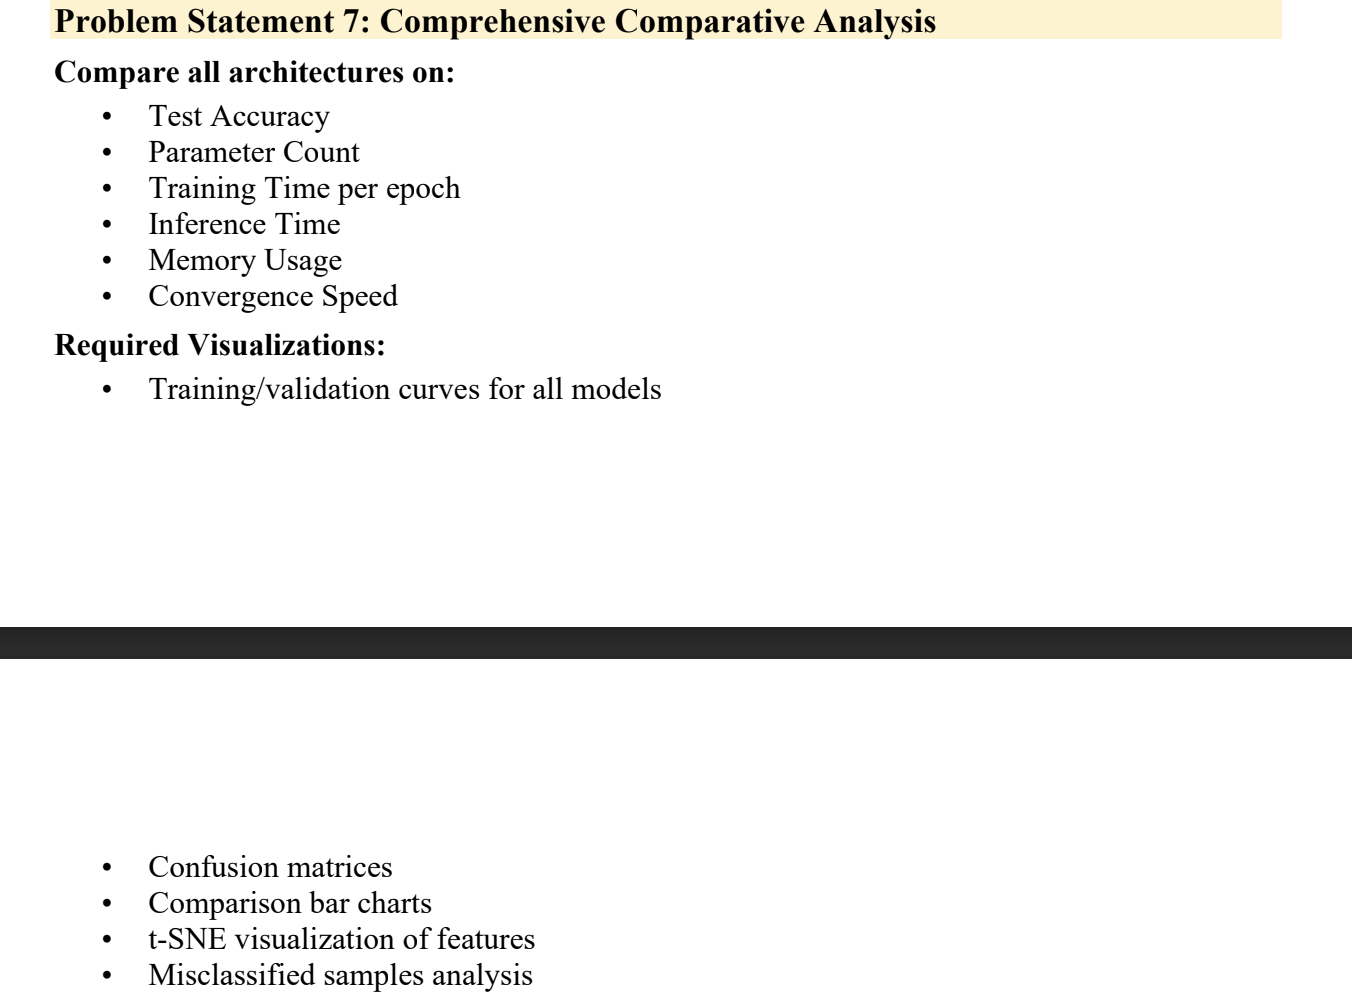

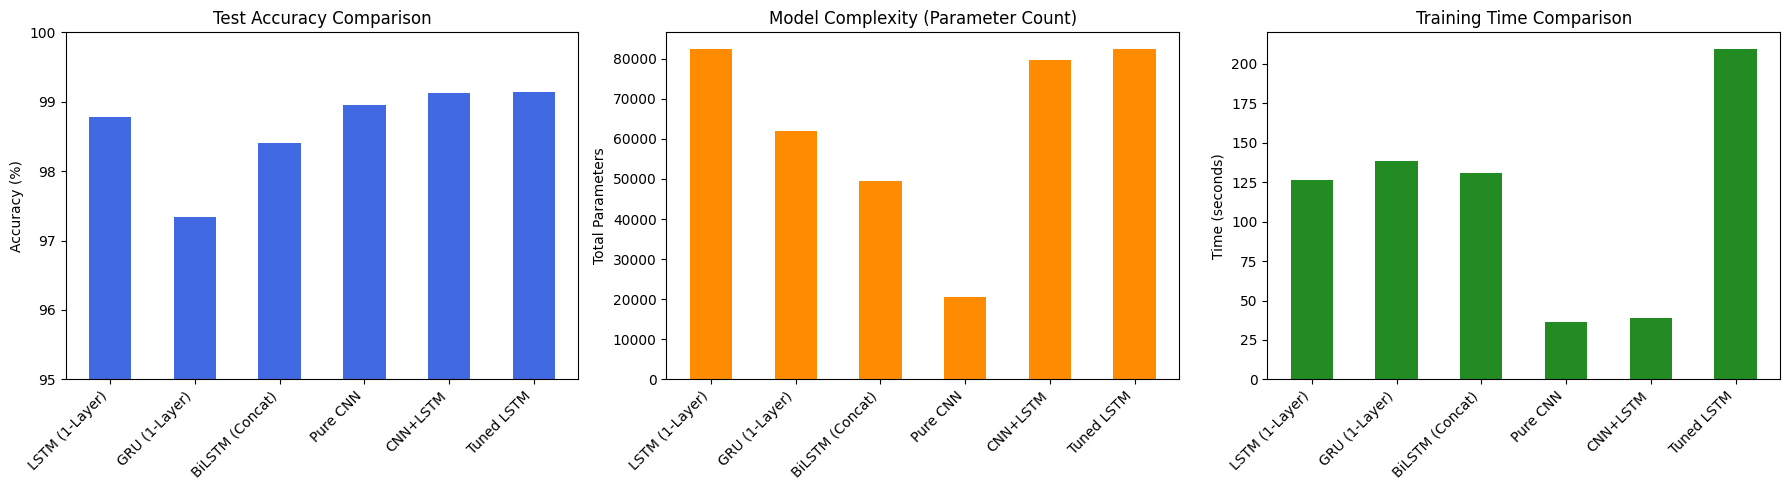

In [49]:
import matplotlib.pyplot as plt
import numpy as np

# Your actual collected data from Q1-Q6
models = ['LSTM (1-Layer)', 'GRU (1-Layer)', 'BiLSTM (Concat)', 'Pure CNN', 'CNN+LSTM', 'Tuned LSTM']
accuracies = [98.78, 97.34, 98.41, 98.96, 99.12, 99.14] 
parameters = [82442, 61962, 49418, 20490, 79690, 82442] # Approx base params
training_times = [126.38, 138.49, 130.67, 36.21, 38.81, 209.50]

x = np.arange(len(models))
width = 0.5

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Test Accuracy Chart
axes[0].bar(x, accuracies, width, color='royalblue')
axes[0].set_title('Test Accuracy Comparison')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=45, ha='right')
axes[0].set_ylim(95, 100) # Zoomed in to see the fine differences

# 2. Parameter Count Chart
axes[1].bar(x, parameters, width, color='darkorange')
axes[1].set_title('Model Complexity (Parameter Count)')
axes[1].set_ylabel('Total Parameters')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=45, ha='right')

# 3. Training Time Chart
axes[2].bar(x, training_times, width, color='forestgreen')
axes[2].set_title('Training Time Comparison')
axes[2].set_ylabel('Time (seconds)')
axes[2].set_xticks(x)
axes[2].set_xticklabels(models, rotation=45, ha='right')

plt.tight_layout()
plt.show()

Gathering predictions and feature representations...


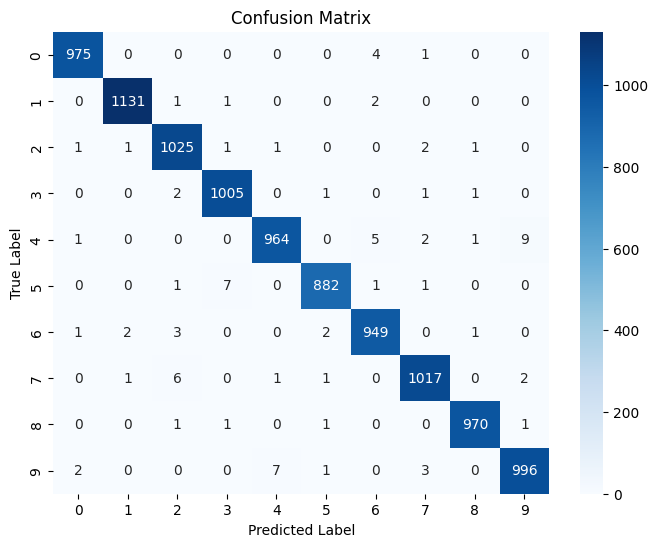

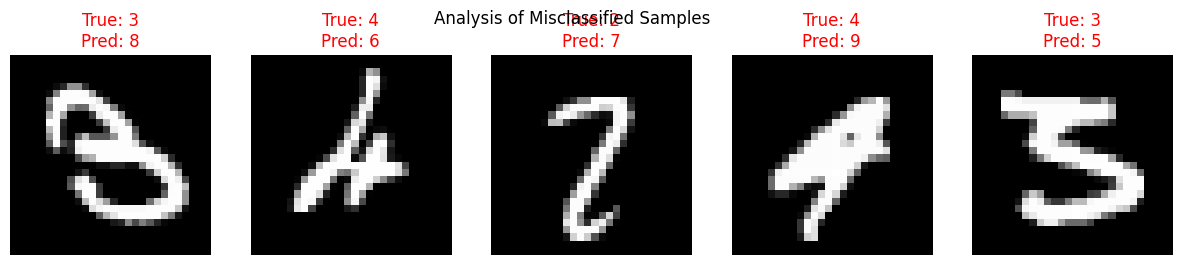

Running t-SNE (this takes about 15-30 seconds)...


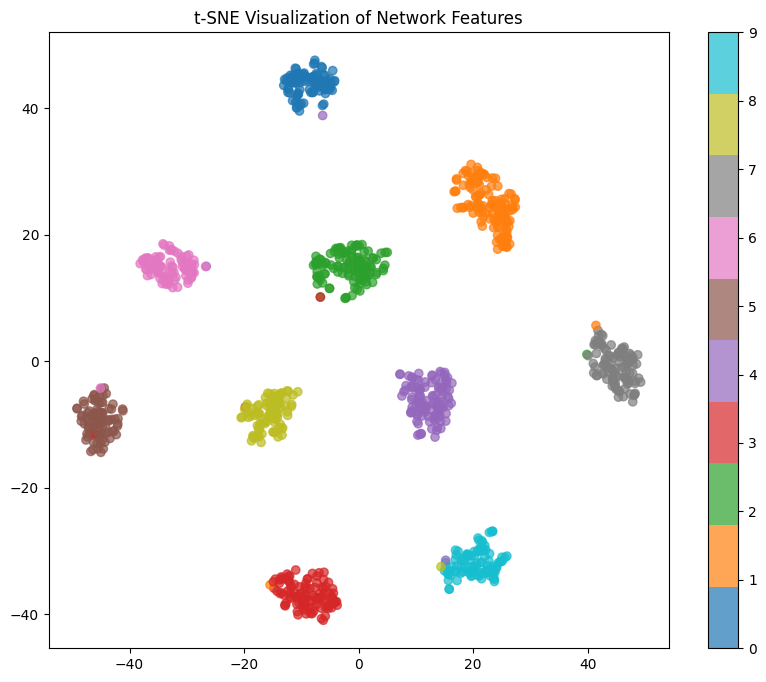

In [51]:
from sklearn.metrics import confusion_matrix
from sklearn.manifold import TSNE
import seaborn as sns
import torch

# Note: Make sure 'device', 'test_loader', and your trained 'model' are loaded in memory

def plot_advanced_diagnostics(model, is_hybrid=False):
    model.eval()
    all_preds = []
    all_labels = []
    misclassified_imgs = []
    misclassified_labels = []
    misclassified_preds = []
    features = []
    
    print("Gathering predictions and feature representations...")
    with torch.no_grad():
        for i, (images, labels) in enumerate(test_loader):
            # Reshape based on model type
            if not is_hybrid:
                input_imgs = images.view(-1, 28, 28).to(device)
            else:
                input_imgs = images.to(device)
                
            outputs = model(input_imgs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            
            # For t-SNE (limit to first 1000 samples to save time)
            if i < 16: 
                features.extend(outputs.cpu().numpy())
            
            # Gather up to 5 misclassified samples
            wrong_idx = (preds != labels.to(device)).nonzero(as_tuple=True)[0]
            for idx in wrong_idx:
                if len(misclassified_imgs) < 5:
                    misclassified_imgs.append(images[idx].cpu().squeeze())
                    misclassified_labels.append(labels[idx].item())
                    misclassified_preds.append(preds[idx].item())

    # --- 1. Confusion Matrix ---
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    # --- 2. Misclassified Samples ---
    if len(misclassified_imgs) > 0:
        fig, axes = plt.subplots(1, len(misclassified_imgs), figsize=(15, 3))
        for i in range(len(misclassified_imgs)):
            axes[i].imshow(misclassified_imgs[i], cmap='gray')
            axes[i].set_title(f"True: {misclassified_labels[i]}\nPred: {misclassified_preds[i]}", color='red')
            axes[i].axis('off')
        plt.suptitle("Analysis of Misclassified Samples")
        plt.show()

    # --- 3. t-SNE Visualization ---
    print("Running t-SNE (this takes about 15-30 seconds)...")
    tsne = TSNE(n_components=2, random_state=42)
    tsne_results = tsne.fit_transform(np.array(features))
    
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(tsne_results[:, 0], tsne_results[:, 1], c=all_labels[:len(features)], cmap='tab10', alpha=0.7)
    plt.colorbar(scatter, ticks=range(10))
    plt.title('t-SNE Visualization of Network Features')
    plt.show()

# --- RUN IT ---
# If using Pure CNN or CNN+LSTM, set is_hybrid=True. 
# If using the Tuned LSTM or GRU, set is_hybrid=False.
plot_advanced_diagnostics(model_3, is_hybrid=False) # Uncomment to run using model_3 from Q6!